In [52]:
import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
conn = sqlite3.connect("../data/inventory.db")

In [44]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
for table in tables['name']:
    print (f' Tabel name: {table}')
    display(pd.read_sql(f"select * from {table} limit 5" ,conn))

 Tabel name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


 Tabel name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


 Tabel name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


 Tabel name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


 Tabel name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [45]:
purchase_agg = pd.read_sql_query("""
select 
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber
""", conn)

In [46]:
pd.read_sql_query("""
select
vi.PONumber,
vi.Quantity AS invoice_quantity,
vi.Dollars AS inovice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate)- julianday(vi.PODate)) AS days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay

from vendor_invoice vi
""" , conn)

,PONumber,invoice_quantity,inovice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [47]:
df = pd.read_sql_query("""
WITH purchase_agg AS(
select 
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber
)
select
vi.PONumber,
vi.Quantity AS invoice_quantity,
vi.Dollars AS invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate)- julianday(vi.PODate)) AS days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay,
pa.total_brands,
pa.total_item_quantity,
pa.total_item_dollars,
pa.avg_receiving_delay

from vendor_invoice vi
LEFT join purchase_agg pa
ON vi.PONumber = pa.PONumber
""" , conn)

In [48]:
df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [49]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [50]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [53]:
def create_invoice_risk_label(row):
    #Invoice total mismatch with item-level total
    if (abs(row["invoice_dollars"] -row["total_item_dollars"]) > 5):
        return 1
    #Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1

    return 0
df["flag_invoice"] = df.apply(create_invoice_risk_label , axis = 1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

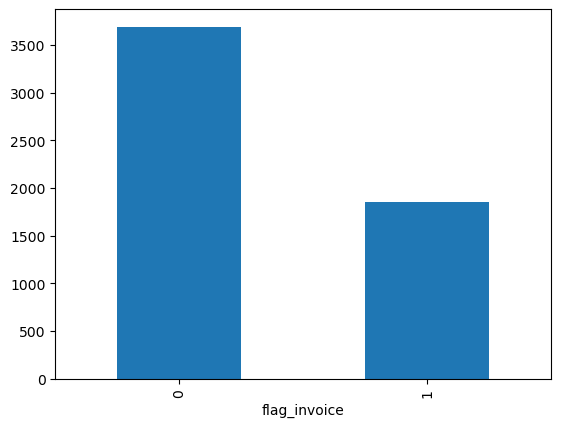

In [54]:
df["flag_invoice"].value_counts().plot(kind = "bar")

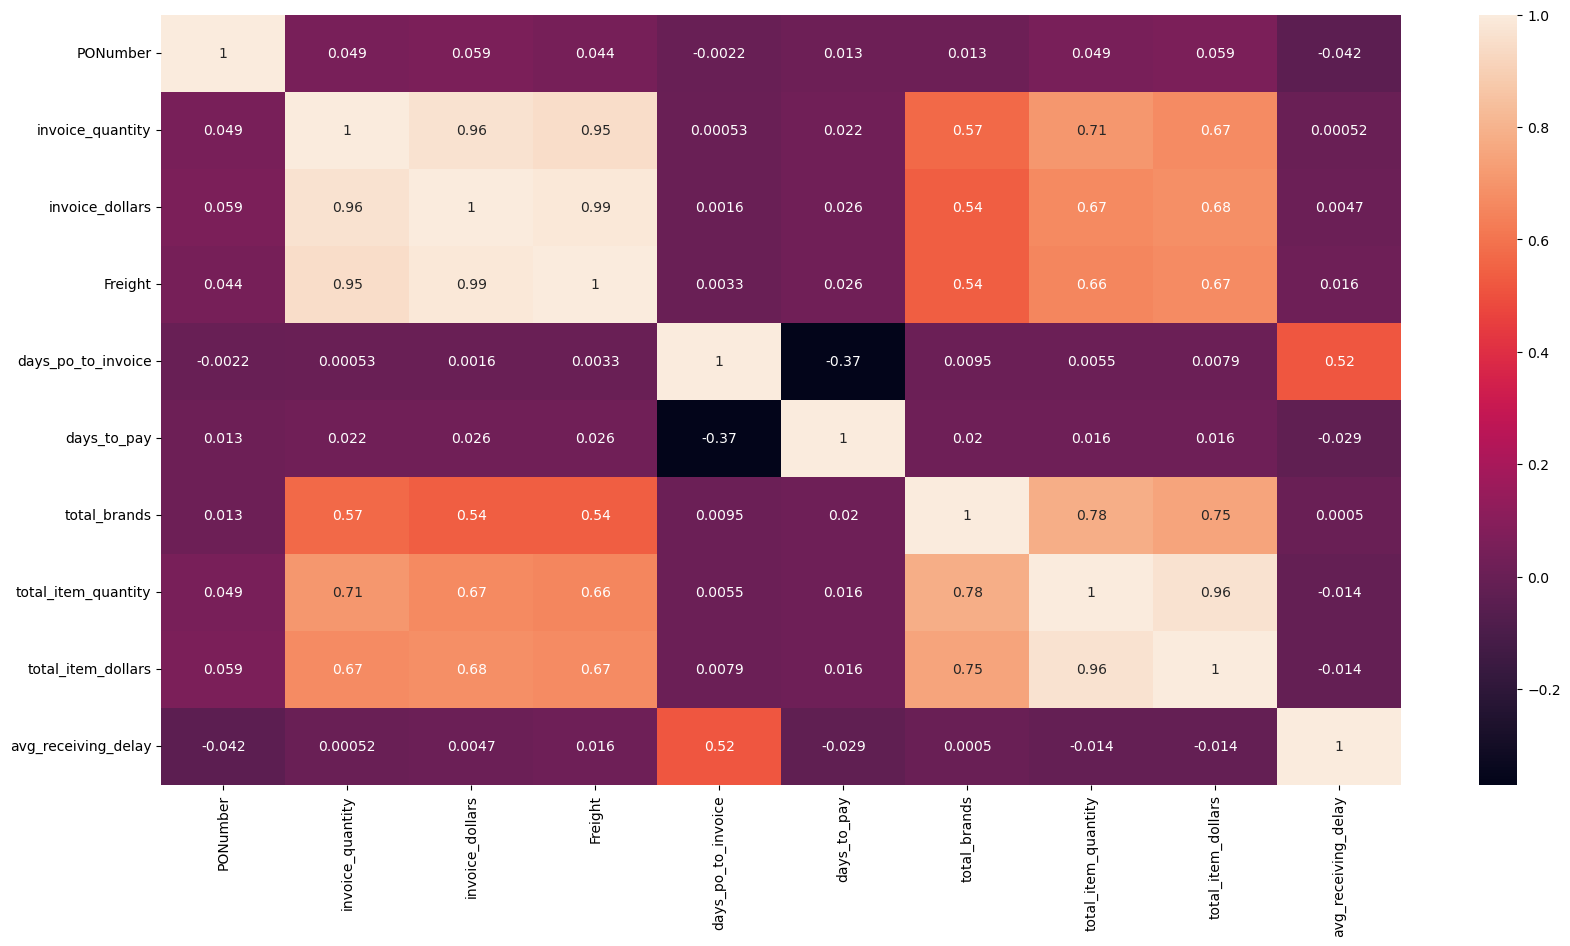

In [13]:
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr() , annot=True)
plt.show()

In [55]:
flagged = df[df["flag_invoice"]==1]
normal = df[df["flag_invoice"]==0]

In [56]:
significant_features =[]
non_significant_features =[]
results =[]

In [57]:
metrices = ['invoice_quantity','invoice_dollars' , 'Freight' , 
            'days_po_to_invoice', 'days_to_pay' , 'total_brands' ,
            'total_item_quantity', 'total_item_dollars' , 'avg_receiving_delay']

In [58]:
from scipy.stats import ttest_ind
for metric in metrices:
    flagged_mean = flagged[metric].mean()
    normal_mean=normal[metric].mean()

    t_stat, p_value =ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var = False
    )

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
        "metric" : metric,
        "flagged_mean" : flagged_mean.round(2),
        "normal_mean" : normal_mean.round(2),
        "p_value" : p_value.round(3)

        })

    else:
        non_significant_features.append(metric)
        

In [59]:
print(non_significant_features)
print(significant_features)

['days_to_pay', 'total_brands']
['invoice_quantity', 'invoice_dollars', 'Freight', 'days_po_to_invoice', 'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']


In [60]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': 6728.28,
  'normal_mean': 5723.55,
  'p_value': 0.021},
 {'metric': 'invoice_dollars',
  'flagged_mean': 65600.61,
  'normal_mean': 54302.64,
  'p_value': 0.008},
 {'metric': 'Freight',
  'flagged_mean': 334.02,
  'normal_mean': 276.89,
  'p_value': 0.008},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': 17.23,
  'normal_mean': 16.02,
  'p_value': 0.0},
 {'metric': 'total_item_quantity',
  'flagged_mean': 6728.28,
  'normal_mean': 5723.55,
  'p_value': 0.021},
 {'metric': 'total_item_dollars',
  'flagged_mean': 65600.61,
  'normal_mean': 54302.64,
  'p_value': 0.008},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': 8.47,
  'normal_mean': 7.27,
  'p_value': 0.0}]

In [61]:
X = df[['invoice_quantity' , 'invoice_dollars' , 'Freight' , 'total_brands' , 'total_item_quantity' , 'days_po_to_invoice' , 'total_item_dollars']]
Y = df['flag_invoice']

In [62]:
from sklearn.model_selection import train_test_split

In [63]:
(X_train , X_test , Y_train , Y_test) = train_test_split(X , Y , test_size=0.2 , random_state = 42)

In [64]:
X_test.shape

(1109, 7)

In [65]:
X.describe().round(3)

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
count,5543.000,5543.000,5543.000,5543.000,5543.000,5543.000,5543.000
mean,6058.881,58073.384,295.954,41.312,6058.881,16.424,58073.384
std,14453.338,140234.031,713.585,76.941,14453.338,3.127,140234.031
min,1.000,4.140,0.020,1.000,1.000,9.000,4.140
25%,83.000,967.810,5.020,3.000,83.000,14.000,967.810
50%,423.000,4765.450,24.730,7.000,423.000,16.000,4765.450
75%,5100.500,44587.175,229.660,46.000,5100.500,19.000,44587.175
max,141660.000,1660435.880,8468.220,807.000,141660.000,23.000,1660435.880


In [66]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [68]:
model1 = LogisticRegression(random_state = 42)
model1.fit(X_train_scaled , Y_train)

model2 = DecisionTreeClassifier(random_state = 42)
model2.fit (X_train_scaled , Y_train)

model3 = RandomForestClassifier(random_state = 42) 
model3.fit(X_train_scaled, Y_train)



RandomForestClassifier(random_state=42)

In [69]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    print(f"{model_name} Performance:")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Classification Report :")
    print(classification_report(y_test, y_pred))
    print("\n")

In [70]:
evaluate_model(model1 , X_test_scaled , Y_test , 'LogisticRegression')
evaluate_model(model2 , X_test_scaled , Y_test , 'Decision Tree Classifier')
evaluate_model(model3 , X_test_scaled , Y_test , 'Random Forest Classifier')


LogisticRegression Performance:
Accuracy : 0.6582506762849414
Classification Report :
              precision    recall  f1-score   support

           0       0.66      0.98      0.79       725
           1       0.56      0.06      0.11       384

    accuracy                           0.66      1109
   macro avg       0.61      0.52      0.45      1109
weighted avg       0.63      0.66      0.55      1109



Decision Tree Classifier Performance:
Accuracy : 0.8115419296663661
Classification Report :
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       725
           1       0.74      0.71      0.72       384

    accuracy                           0.81      1109
   macro avg       0.79      0.79      0.79      1109
weighted avg       0.81      0.81      0.81      1109



Random Forest Classifier Performance:
Accuracy : 0.8764652840396754
Classification Report :
              precision    recall  f1-score   support

           0     

In [71]:
model3.feature_importances_

array([0.15137944, 0.15122699, 0.14480642, 0.07920458, 0.17671025,
       0.07717963, 0.21949268])

In [72]:
feature_importance=pd.DataFrame({
    "feature" : X_train.columns, 
    "importance" : model3.feature_importances_
}).sort_values(by = "importance" , ascending =False)

feature_importance

,feature,importance
6,total_item_dollars,0.219493
4,total_item_quantity,0.176710
0,invoice_quantity,0.151379
1,invoice_dollars,0.151227
2,Freight,0.144806
3,total_brands,0.079205
5,days_po_to_invoice,0.077180


In [73]:
X = df[['invoice_quantity' , 'invoice_dollars' , 'Freight' , 'total_item_quantity' , 'total_item_dollars']]
Y = df['flag_invoice']

In [74]:
(X_train , X_test , Y_train , Y_test) = train_test_split(X , Y , test_size=0.2 , random_state = 42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model3 = RandomForestClassifier(random_state = 42) 
model3.fit(X_train_scaled, Y_train)

evaluate_model(model3 , X_test_scaled , Y_test , 'Random Forest Classifier')



Random Forest Classifier Performance:
Accuracy : 0.8845807033363391
Classification Report :
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       725
           1       0.94      0.72      0.81       384

    accuracy                           0.88      1109
   macro avg       0.90      0.84      0.86      1109
weighted avg       0.89      0.88      0.88      1109





HYPERPARAMETERS

In [75]:
param_grid = {
    "n_estimators" : [100, 200 , 300],
    "max_depth": [None , 4, 5, 6],
    "min_samples_split" : [2, 3 ,5],
    "min_samples_leaf" : [1, 2, 5],
    "criterion" : ['gini' , 'entropy']
}

In [76]:
from sklearn.metrics import make_scorer , f1_score
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(random_state = 42 , n_jobs =-1)

scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator = rf, 
    param_grid = param_grid,
    scoring = scorer,
    cv=5, 
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, Y_train)
evaluate_model(grid_search , X_test_scaled , Y_test, 'Random Forest Classifier')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Random Forest Classifier Performance:
Accuracy : 0.8899909828674482
Classification Report :
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       725
           1       0.96      0.71      0.82       384

    accuracy                           0.89      1109
   macro avg       0.91      0.85      0.87      1109
weighted avg       0.90      0.89      0.89      1109





In [81]:
from sklearn.metrics import confusion_matrix

In [82]:
confusion_matrix(grid_search.predict(X_test_scaled) ,Y_test)

array([[713, 110],
       [ 12, 274]], dtype=int64)

In [83]:
confusion_matrix(model3.predict(X_test_scaled) , Y_test)

array([[706, 109],
       [ 19, 275]], dtype=int64)

In [84]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 300}